In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import marapendi as mrpd

In [6]:
# Parameters not estimated for n=18 (held at initial guess / structural defaults).
fixed_parameters = {
    # structural
    "ionomer-k1": 8.5,
    "ionomer-k2": 5.4,
    "ionomer-k3": 5.4,
    "gdl-porosity": 0.6,
    "pt-wt-percent": 0.4,
    "ch-height": 1e-3,
    "cl-thermal-cond": 0.22,
    # not estimated in n=18 run (initial-guess values from estimation notebook)
    "radius-carbon":    25e-9,
    "n_s":              2.0,
    "tcr":              4.4e-4,
    "gdl-thickness":    150e-6,
    "gdl-theta":        120.,
    "gdl-eff-diff-ratio": 0.3,
    "cl-abs-perm":      1e-13,
    "wet-transition":   0.4,
    "pt-loading":       0.3e-2,
    "ic-ratio":         1.4,
    "ecsa":             60e3,
    "memb-thickness":   12e-6,
    "memb-water-diff":  2e-10,
    "E-act-memb-diff":  20e6,
    "E-act-memb-abs":   20e6,
    "cl-theta":         97.,
    "cl-pore-diameter": 40e-9,
}

# n_parameters = 18, test_case = 1 from
# results_final_estimation_model2_new_perm_lim_Affonso_Nobrega_et_al_2026_JES.csv
estimated_parameters = {
    "elec-resistance":    2.9530648896871747e-06,
    "alpha-c":            0.9787267578804776,
    "memb-cond-correction": 0.5931184249543466,
    "B_ch":               1.569658726740594,
    "ionomer-cond-corr":  0.1,
    "i0-c":               0.0006132821187989,
    "E-act-ca":           70077131.152351,
    "Sh":                 1.1178521443320013,
    "gdl-thermal-cond":   0.0535602714122958,
    "memb-cond-exp":      1.00388833110202,
    "memb-abs-constant":  6.833163380363523e-05,
    "memb-E-act-cond":    24978440.12951827,
    "memb-equiv-weight":  722.4590540355077,
    "gamma-c":            0.9489498237559876,
    "ix-corr":            1.9981101254106688,
    "ionomer-cond-exp":   1.0,
    "ionomer-E-act-cond": 23316759.796687774,
    "gdl-abs-perm":       6.936859092132142e-13,
}

params = {**fixed_parameters, **estimated_parameters}


def create_cell(params):
    class NewPermModel(mrpd.HydrogenPermeationModel):
        def permeation_flux(self, membrane_thickness, partial_pressure_h2,
                            temperature, pressure_difference, water_vol_fraction):
            return self.permeability_correction_factor * (
                15.7e-9 * np.exp(-20280 / 8.3415 / temperature)
                + water_vol_fraction * 45e-9 * np.exp(-18930 / 8.3145 / temperature)
            ) / 1000 * 100 / 1e5 * partial_pressure_h2 / membrane_thickness

    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params["memb-equiv-weight"], dry_density=2000.,
            conductivity_exp=params["memb-cond-exp"],
            conductivity_activation_energy=params["memb-E-act-cond"],
            conductivity_correction=params["memb-cond-correction"],
            reference_water_diffusivity=params["memb-water-diff"],
            reference_water_absorption_coefficient=params["memb-abs-constant"],
            water_diffusivity_activation_energy=params["E-act-memb-diff"],
            water_absorption_activation_energy=params["E-act-memb-abs"],
        ),
        dry_thickness=params["memb-thickness"],
        h2_permeation_model=NewPermModel(permeability_correction_factor=params["ix-corr"]),
    )
    orr = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params["i0-c"],
        reaction_order=params["gamma-c"], activation_energy=params["E-act-ca"],
        reference_activity=1.01325e5, reference_temperature=353.15,
        number_of_electrons=1, charge_transfer_coeff=params["alpha-c"],
    )
    liq = mrpd.DarcyTransportModel(J_function_exponent=params["wet-transition"])
    gdl = {s: mrpd.GasDiffusionLayer(
        thickness=params["gdl-thickness"], contact_angle=params["gdl-theta"],
        effective_gas_diffusion_ratio=params["gdl-eff-diff-ratio"],
        absolute_permeability=params["gdl-abs-perm"], porosity=params["gdl-porosity"],
        thermal_conductivity=params["gdl-thermal-cond"], two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(
            water_saturation_exponent=params["n_s"]),
    ) for s in ["ca", "an"]}
    ch = {s: mrpd.FlowChannel(
        height=params["ch-height"], width=1e-3, n_parallel=1, length=21 * 50e-3,
        reactant="o2" if s == "ca" else "h2",
        transport_resistance_model=mrpd.ChannelGasResistanceModel(
            sherwood=params["Sh"], B_ch=params["B_ch"]),
    ) for s in ["an", "ca"]}
    ion = mrpd.PFSAIonomer(
        conductivity_correction=params["ionomer-cond-corr"],
        conductivity_exp=params["ionomer-cond-exp"],
        conductivity_activation_energy=params["ionomer-E-act-cond"],
    )
    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params["ecsa"], platinum_loading=params["pt-loading"], ionomer=ion,
        catalyst_platinum_weight_percent=params["pt-wt-percent"],
        ionomer_to_carbon_ratio=params["ic-ratio"],
        ionomer_k1=params["ionomer-k1"], ionomer_k2=params["ionomer-k2"],
        ionomer_k3=params["ionomer-k3"],
        pore_diameter=params["cl-pore-diameter"], omega_PtO=0,
        carbon_agglomerate_radius=params["radius-carbon"],
        thickness=params["pt-loading"] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params["cl-abs-perm"], contact_angle=params["cl-theta"],
        thermal_conductivity=params["cl-thermal-cond"], reaction=orr,
        two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )
    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params["ecsa"], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params["pt-wt-percent"],
        ionomer_to_carbon_ratio=params["ic-ratio"], ionomer=ion,
        pore_diameter=params["cl-pore-diameter"],
        carbon_agglomerate_radius=params["radius-carbon"],
        thickness=2.8e-6, absolute_permeability=params["cl-abs-perm"],
        contact_angle=params["cl-theta"], thermal_conductivity=params["cl-thermal-cond"],
        two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )
    return mrpd.FuelCell(
        electrical_resistance=params["elec-resistance"], area=25e-4,
        ca=mrpd.FuelCellSide(cl=ca_cl, gdl=gdl["ca"], has_gdl=True, has_mpl=False,
                              ch=ch["ca"], thermal_contact_resistance=params["tcr"]),
        an=mrpd.FuelCellSide(cl=an_cl, gdl=gdl["an"], has_gdl=True, has_mpl=False,
                              ch=ch["an"], thermal_contact_resistance=params["tcr"]),
        membrane=membrane,
    )


cell = create_cell(params)
print("Cell assembled.")

Cell assembled.


Piecewise linear regression  RH(λ$_eq$)  (T = 353 K, 3 segments)

Fitting intervals (RH) : [0.0, 0.1796, 0.6025, 1.0]
Validity intervals (λ) : [0.043, 2.0468, 3.7997, 13.373]
  (boundaries = line intersections → continuity guaranteed)

k    Validity λ interval         a_k (slope)  b_k (intercept)
──────────────────────────────────────────────────────────────
0    λ ∈ [0.0430, 2.0468]           0.088607          -0.017309
       RH = 0.088607 · λ − 0.017309
1    λ ∈ [2.0468, 3.7997]           0.280693          -0.410471
       RH = 0.280693 · λ − 0.410471
2    λ ∈ [3.7997, 13.3730]           0.040755           0.501222
       RH = 0.040755 · λ + 0.501222


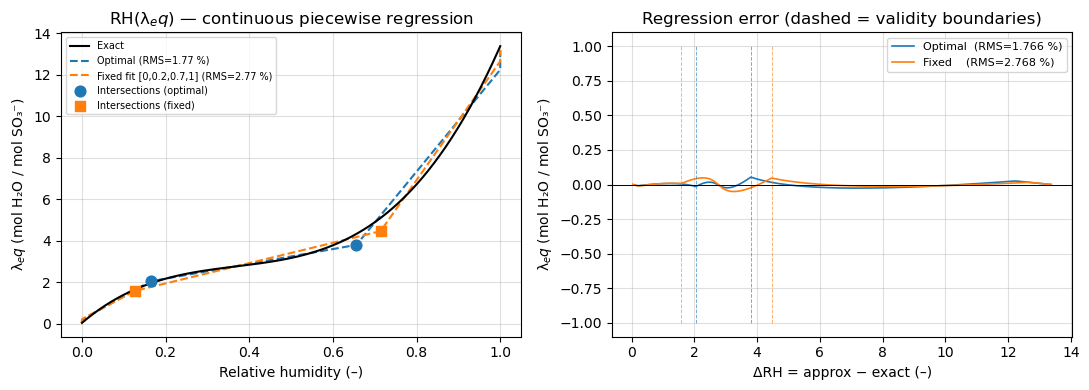

In [7]:
ionomer = cell.membrane.ionomer   # PFSAIonomer — fitted at __post_init__
T_REF = ionomer.pwl_temperature

rh_ref   = np.linspace(0.0, 1.0, 500)
lmbd_ref = ionomer.vapor_equilibrium_water_content(rh_ref, T_REF)

# ── Print segment expressions ──────────────────────────────────────────────────
n_seg = len(ionomer.pwl_slopes)
print(f"Piecewise linear regression  RH(λ$_eq$)  (T = {T_REF:.0f} K, {n_seg} segments)\n")
print(f"Fitting intervals (RH) : {np.round(ionomer.fit_rh_breaks, 4).tolist()}")
print(f"Validity intervals (λ) : {np.round(ionomer.lmbd_pwl_breaks, 4).tolist()}")
print(f"  (boundaries = line intersections → continuity guaranteed)\n")
print(f"{'k':<4} {'Validity λ interval':<24} {'a_k (slope)':>14} {'b_k (intercept)':>16}")
print("─" * 62)
for k, (a, b, lo, hi) in enumerate(zip(
    ionomer.pwl_slopes, ionomer.pwl_intercepts,
    ionomer.lmbd_pwl_breaks[:-1], ionomer.lmbd_pwl_breaks[1:],
)):
    sign = '+' if b >= 0 else '−'
    print(f"{k:<4} λ ∈ [{lo:.4f}, {hi:.4f}]     {a:>14.6f}   {b:>16.6f}")
    print(f"       RH = {a:.6f} · λ {sign} {abs(b):.6f}")

# ── Compare with fixed fitting intervals [0, 0.2, 0.7, 1] ────────────────────
fixed_fit_breaks = np.array([0.0, 0.2, 0.7, 1.0])
ionomer.fit_rh_piecewise_linear(rh_breaks=fixed_fit_breaks, temperature=T_REF)
rh_fixed = ionomer.linear_rh_from_water_content(lmbd_ref)
lmbd_valid_fixed = ionomer.lmbd_pwl_breaks.copy()
rh_valid_fixed   = ionomer.rh_pwl_breaks.copy()

# Restore optimal fit
ionomer.fit_rh_piecewise_linear(temperature=T_REF)
rh_opt       = ionomer.linear_rh_from_water_content(lmbd_ref)
lmbd_valid_opt = ionomer.lmbd_pwl_breaks.copy()
rh_valid_opt   = ionomer.rh_pwl_breaks.copy()

rms_opt   = np.sqrt(np.mean((rh_opt   - rh_ref) ** 2))
rms_fixed = np.sqrt(np.mean((rh_fixed - rh_ref) ** 2))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(rh_ref, lmbd_ref,   'k',    lw=1.5, label='Exact', zorder=3)
ax.plot(rh_opt[:-2], lmbd_ref[:-2],    'C0--', lw=1.5, label=f'Optimal (RMS={rms_opt*100:.2f} %)')
ax.plot(rh_fixed[:-2], lmbd_ref[:-2],  'C1--',  lw=1.5, label=f'Fixed fit [0,0.2,0.7,1] (RMS={rms_fixed*100:.2f} %)')
# Mark validity-interval boundaries (intersections)
ax.scatter(rh_valid_opt[1:-1], lmbd_valid_opt[1:-1],      color='C0', zorder=5, s=60, label='Intersections (optimal)')
ax.scatter(rh_valid_fixed[1:-1], lmbd_valid_fixed[1:-1],  color='C1', zorder=5, s=60, marker='s', label='Intersections (fixed)')

ax.set_ylabel('λ$_eq$ (mol H₂O / mol SO₃⁻)')
ax.set_xlabel('Relative humidity (–)')
ax.set_title('RH(λ$_eq$) — continuous piecewise regression')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(lmbd_ref, rh_opt   - rh_ref, 'C0', lw=1.2, label=f'Optimal  (RMS={rms_opt*100:.3f} %)')
ax.plot(lmbd_ref, rh_fixed - rh_ref, 'C1', lw=1.2, label=f'Fixed    (RMS={rms_fixed*100:.3f} %)')
ax.axhline(0, color='k', lw=0.7)
ax.vlines(lmbd_valid_opt[1:-1],   -1, 1, colors='C0', lw=0.7, ls='--', alpha=0.6)
ax.vlines(lmbd_valid_fixed[1:-1], -1, 1, colors='C1', lw=0.7, ls='--', alpha=0.6)
ax.set_ylabel('λ$_eq$ (mol H₂O / mol SO₃⁻)')
ax.set_xlabel('ΔRH = approx − exact (–)')
ax.set_title('Regression error (dashed = validity boundaries)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

fig.tight_layout()
plt.show()